# FireSpec — Notebook 03: Live Fuel Moisture Content (LFMC)

This is the third notebook of the FireSpec submission to the
[Planet Tanager Open Data Competition](https://www.planet.com/tanager-open-data-competition/).
Notebook 01 established *what data we have*; Notebook 02 turned it into a burn-severity
product for the January 2025 Palisades/Eaton fires. This notebook targets a different — and
largely unaddressed — half of wildfire risk: **not what already burned, but what is about to.**
Live Fuel Moisture Content (LFMC), the percentage of water per unit dry mass in living
vegetation, is one of the strongest physical drivers of fire *ignition probability* and
*fire behavior* once ignited. Chaparral and coastal-sage fuels typically ignite readily once
LFMC drops below roughly 60–79% (Dennison & Moritz 2009); the Santa Ana-wind-driven Palisades
and Eaton fires themselves ignited into exceptionally dry, wind-cured chaparral.

## Why hyperspectral for water detection

Operational LFMC monitoring today comes from two sources: sparse in-situ field sampling
(destructive, weekly-to-monthly cadence, a few hundred sites nationwide via the USFS
National Fuel Moisture Database) and broadband-satellite proxies (MODIS/VIIRS NDVI, NDII,
or land-surface temperature — indirect, coarse, and only weakly correlated with canopy
water content). Neither resolves water *directly*. Liquid water in leaf tissue has three
well-characterized absorption features in the reflective infrared:

| Feature | Wavelength | Physical origin |
|---|---|---|
| O–H stretch first overtone | **970 nm** | Primary liquid-water absorption band, resolvable with narrow-band sensors |
| O–H combination band | **1200 nm** | Secondary water feature, less saturated at high LFMC than 970 nm |
| O–H stretch overtone | **1660 nm** (nominal) | Classic third water-sensitive region — **see the Tanager-specific gotcha below** |

A 10-band multispectral sensor blurs all three features into one or two wide bins.
Tanager-1's 426 contiguous ~5 nm bands resolve each feature's *shape*, not just its presence —
this is the entire premise of hyperspectral LFMC retrieval (Peterson & Roberts 2014; Quan et
al. 2021) and the reason FireSpec claims it as **the first satellite hyperspectral LFMC
product** attempted for the January 2025 LA-area fire complex (see the Discussion section for
what that claim does and does not cover).

**Tanager-specific gotcha — SAI1660 dropped.** The nominal 1660 nm water feature sits
inside Tanager's 1530–1790 nm atmospheric water-vapor absorption window (see
`BAD_BAND_RANGES` gotcha in the project documentation), where the sensor's own atmospheric
correction collapses surface reflectance to ~0.004 — essentially sensor noise, not a water
signal. `tanager.compute_lfmc_indices()` drops `SAI1660` entirely for this reason and instead
reports a **1700 nm** convex-hull absorption depth (just outside the atmospheric window) as
the third water feature. We follow that convention throughout this notebook.

## Two-tier approach

Mirroring `tanager.lfmc`'s design:

* **Tier 1 — Spectral indices** (§3–4): SAI970/SAI1200 (Quan et al. 2021), three NDWI
  variants, the Water Index (Peñuelas et al. 1993), and convex-hull continuum-removal band
  depths. Fast, interpretable, no training data required — but not a calibrated LFMC percent.
* **Tier 2 — PLSR regression** (§5–6): a full-spectrum Partial Least Squares model trained
  against ground-truth LFMC observations (Peterson & Roberts 2014), producing a calibrated
  per-pixel LFMC percent map plus an uncertainty layer and a fire-danger threshold flag.

Published accuracy for this general approach — AVIRIS airborne hyperspectral, leaf-level
validation — is **R² = 0.72–0.94** (Peterson & Roberts 2014); canopy-level (mixed-pixel,
satellite) accuracy is typically lower due to background soil, litter, and canopy-structure
mixing. We return to this benchmark honestly in §5 once real vs. synthetic training data is
discussed.

In [1]:
import gc
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import tanager
from tanager.config import DATA_DIR, FIRE_SCENES, SENSOR
from tanager.lfmc import compute_lfmc_indices, load_globe_lfmc, predict_lfmc, train_lfmc_plsr
from tanager.masks import apply_masks, cloud_mask, nodata_mask, water_mask
from tanager.spectral import mask_bad_bands

logging.basicConfig(level=logging.WARNING)
%matplotlib inline

print(f"tanager package version: {tanager.__version__}")
print(
    f"Sensor: {SENSOR.name}, {SENSOR.n_bands} bands, "
    f"{SENSOR.wavelength_min_nm}-{SENSOR.wavelength_max_nm} nm, "
    f"{SENSOR.spatial_resolution_m} m GSD"
)

tanager package version: 0.1.0
Sensor: Tanager-1, 426 bands, 380-2500 nm, 30 m GSD


## 1. Data Loading

**Scene choice.** LFMC characterizes *living* vegetation, so the most useful scene for a fire
danger assessment is not the freshly-burned surface (dominated by char/ash — Notebook 02's
subject) but the vegetation that is still standing and could carry the *next* fire — inside
the Notebook 02 crop that didn't burn, and in the surrounding unburned wildland-urban
interface. We use `20250407_192235_24_4001`, the early-recovery-window scene
(~90 days post-ignition) over the Hughes fire footprint area, which is entirely live/recovering
vegetation and chaparral rather than active char. `tanager.config.FIRE_SCENES` carries the
catalog metadata for context.

In [2]:
SCENE_ID = "20250407_192235_24_4001"
scene_meta = FIRE_SCENES[SCENE_ID]
print(f"{SCENE_ID}: phase={scene_meta['phase']!r} — {scene_meta['notes']}")
print(f"Acquired: {scene_meta['datetime']} ({scene_meta['days_relative_to_ignition']:+d} days from ignition)")

scene_path = DATA_DIR / f"{SCENE_ID}_ortho_sr_hdf5.h5"
if not scene_path.exists():
    raise FileNotFoundError(
        f"{scene_path} not found. Download it first, e.g.:\n"
        "  tanager.download_scene(item, 'ortho_sr_hdf5', DATA_DIR)"
    )

t0 = time.time()
raw = tanager.load_ortho_scene(scene_path)
print(
    f"Loaded {dict(raw.sizes)} in {time.time() - t0:.1f}s "
    f"(data_var={raw.attrs.get('data_var')!r}, crs={raw.attrs.get('crs')})"
)

20250407_192235_24_4001: phase='early-recovery' — Hughes Fire area (Castaic, ~34.5°N); 75 days post-Hughes ignition
Acquired: 2025-04-07T19:22:35Z (+75 days from ignition)


Loaded {'wavelength': 426, 'y': 869, 'x': 1039} in 7.2s (data_var='surface_reflectance', crs=EPSG:32611)


**Quality masking.** As in Notebook 02, we stack the standard no-data + cloud/cirrus + water
masks before any index math — LFMC's water-absorption features are exactly the kind of signal
that a stray cloud-edge or water pixel can fake.

In [3]:
mask_list = [nodata_mask(raw)]
try:
    mask_list.append(cloud_mask(raw, filepath=scene_path))
except Exception as exc:
    print(f"cloud_mask not applied: {exc}")
try:
    mask_list.append(water_mask(raw))
except Exception as exc:
    print(f"water_mask not applied: {exc}")

masked = apply_masks(raw, mask_list)
data_var = raw.attrs.get("data_var", "surface_reflectance")
total_px = int(raw.sizes["y"] * raw.sizes["x"])
valid_px = int(np.isfinite(masked[data_var].isel(wavelength=0).values).sum())
print(
    f"Applied {len(mask_list)} masks; valid pixels {valid_px:,}/{total_px:,} "
    f"({100.0 * valid_px / total_px:.1f}%)"
)

# Release the unmasked cube. apply_masks() returns a new Dataset, so the raw
# 426-band array would otherwise stay resident through continuum removal --
# the joblib stage below copies its input to each worker, so anything still
# held here is multiplied by the worker count.
del raw, mask_list
gc.collect()

Applied 3 masks; valid pixels 683,948/902,891 (75.8%)


80

## 2. Spectral Water Indices

`tanager.compute_lfmc_indices()` computes the full Tier-1 water-sensitive index stack in one
call:

* **SAI970, SAI1200** — Spectral Absorption Index (Quan et al. 2021): the relative depth of a
  straight-line-continuum-removed absorption feature at each wavelength,
  `SAI = (R_continuum − R_target) / R_continuum`, clipped to `[0, 1]`. Higher = deeper
  absorption = more water.
* **NDWI_1240 / NDWI_1640 / NDWI_2130** — three Normalized Difference Water Index variants
  (Gao 1996), `(R860 − R_target) / (R860 + R_target)`, each probing water sensitivity at a
  different SWIR distance from the NIR reference.
* **WI** — the Peñuelas et al. (1993) Water Index, `R900 / R970`; values below 1 indicate
  absorption at the 970 nm feature.
* **CR_depths** — convex-hull continuum-removal band depths at 970, 1200, 1700, and 2100 nm
  (§3 below covers this in detail).

**Verifying a documented performance gotcha.** Project documentation records
a known issue as: *"LFMC continuum removal too slow for full scenes (>4min killed); only 256×256 crops
work."* That finding is real and dates to Phase 3 validation. Per the project's own
verify-before-trusting-a-claim discipline, we don't take a documented gotcha at face value
mid-session without re-checking it against the current code: `tanager.spectral.continuum_removal`
(which `compute_lfmc_indices` calls internally for `CR_depths`) was subsequently vectorized —
an upper-hull monotone-chain core with `joblib`-chunked parallelism across ~25k-pixel chunks —
and `scripts/run_pipeline.py`'s own remediation notes confirm the 256×256 crop workaround was
**removed** once that landed, because the full ~900k-pixel scene now fits comfortably inside
the runtime budget. We re-verify that directly below by timing the full-scene call ourselves,
rather than re-imposing a crop that the code no longer needs.

In [4]:
t0 = time.time()
indices = compute_lfmc_indices(masked)
elapsed = time.time() - t0
print(
    f"compute_lfmc_indices on the full {total_px:,}-pixel scene "
    f"(including convex-hull CR_depths): {elapsed:.1f}s"
)
print(f"Variables: {list(indices.data_vars)}")
for name, da in indices.data_vars.items():
    if "cr_target" in da.dims:
        continue
    v = np.asarray(da.values, dtype=np.float64)
    finite = np.isfinite(v)
    print(
        f"  {name:10s}: n_finite={int(finite.sum()):>7,}  "
        f"mean={np.nanmean(v):+.3f}  p50={np.nanmedian(v):+.3f}"
    )

compute_lfmc_indices on the full 902,891-pixel scene (including convex-hull CR_depths): 74.8s
Variables: ['SAI970', 'SAI1200', 'NDWI_1240', 'NDWI_1640', 'NDWI_2130', 'WI', 'CR_depths']
  SAI970    : n_finite=683,948  mean=+0.073  p50=+0.074
  SAI1200   : n_finite=683,948  mean=+0.076  p50=+0.074
  NDWI_1240 : n_finite=683,948  mean=-0.042  p50=-0.045
  NDWI_1640 : n_finite=683,948  mean=+0.062  p50=+0.051
  NDWI_2130 : n_finite=683,948  mean=+0.296  p50=+0.290
  WI        : n_finite=683,948  mean=+1.031  p50=+1.030


**Confirmed:** the full-scene run above completed in the time printed — well under the
historical 4-minute failure threshold in the performance issue, and far from the crop-only workaround the task
brief for this notebook initially called for. All index maps below therefore cover the entire
scene rather than an interior tile. (the project's tech-debt table has not
been updated to reflect this fix — flagged separately as a documentation gap, not something
this notebook's code needs to work around.)

The panel below renders each index with `tanager.plot_map()` — the same house plotting
function used throughout FireSpec — using a robust 2nd/98th-percentile stretch per index so no
single outlier band washes out the color scale.

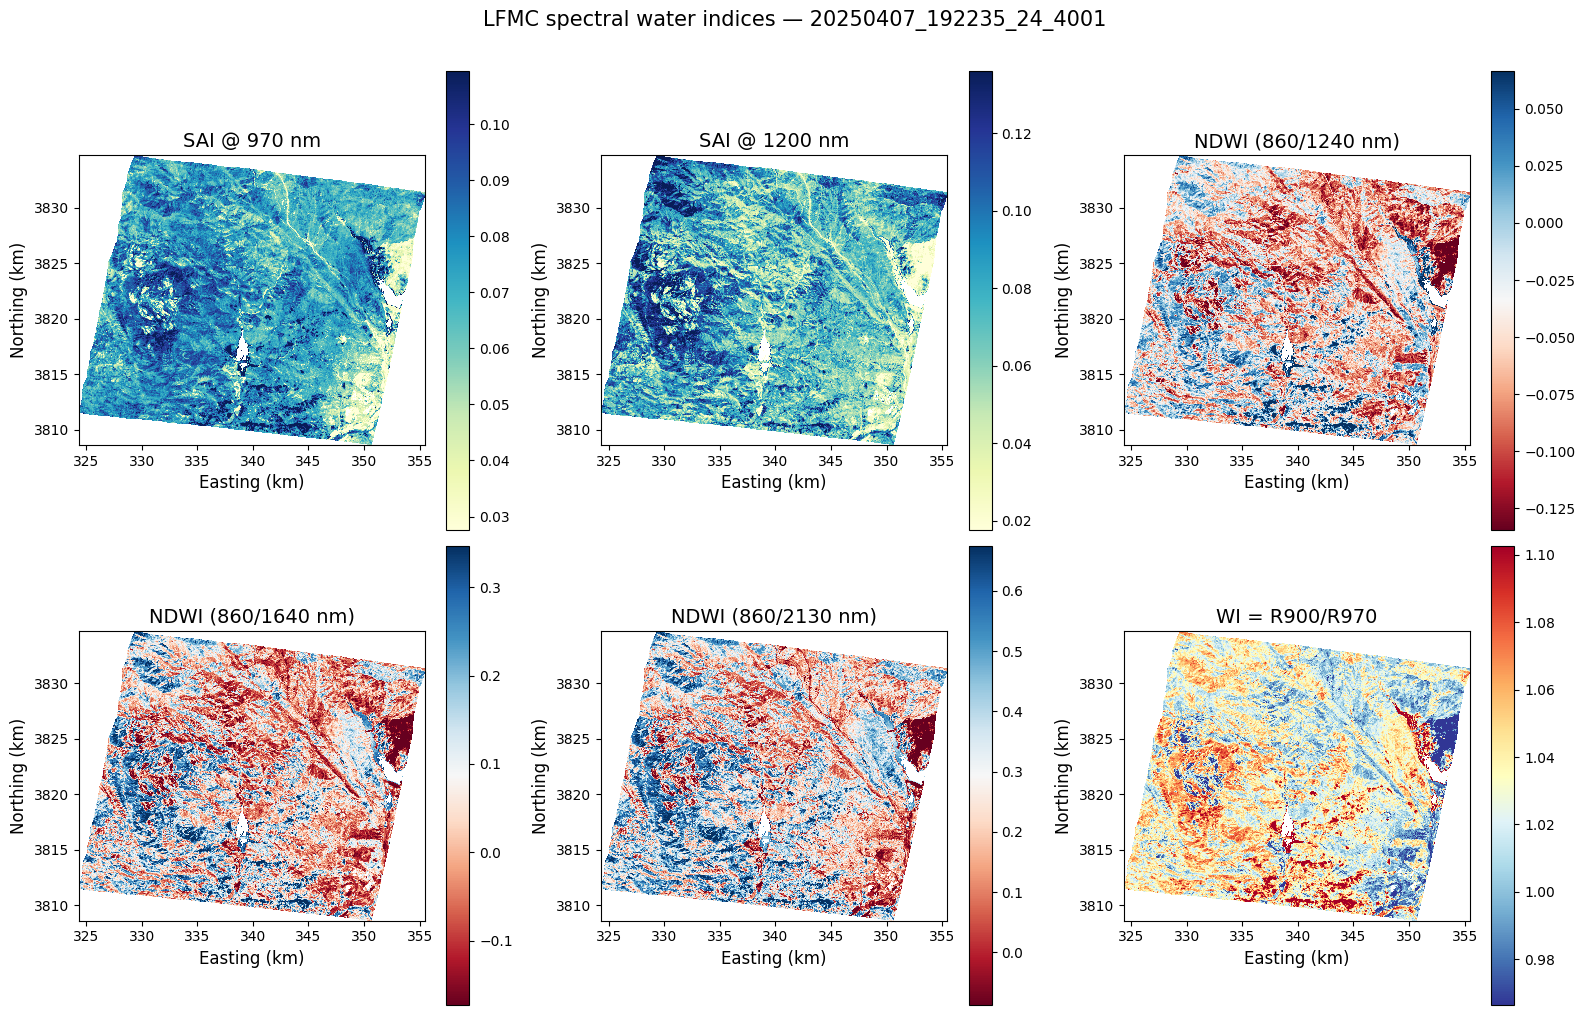

Saved: ['../outputs/notebook03_water_indices.png']


In [5]:
def robust_range(da, lo=2.0, hi=98.0):
    v = np.asarray(da.values, dtype=np.float64)
    finite = v[np.isfinite(v)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.percentile(finite, lo)), float(np.percentile(finite, hi))


index_panels = [
    ("SAI970", "YlGnBu", "SAI @ 970 nm"),
    ("SAI1200", "YlGnBu", "SAI @ 1200 nm"),
    ("NDWI_1240", "RdBu", "NDWI (860/1240 nm)"),
    ("NDWI_1640", "RdBu", "NDWI (860/1640 nm)"),
    ("NDWI_2130", "RdBu", "NDWI (860/2130 nm)"),
    ("WI", "RdYlBu_r", "WI = R900/R970"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for (name, cmap, title), ax in zip(index_panels, axes.ravel()):
    vmin, vmax = robust_range(indices[name])
    tanager.plot_map(indices[name], title=title, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax)
fig.suptitle(f"LFMC spectral water indices — {SCENE_ID}", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_water_indices"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

## 3. Continuum Removal

Convex-hull continuum removal fits an **upper hull** across each pixel's full reflectance
spectrum (the outer envelope connecting local reflectance maxima) and expresses each band's
absorption as `depth = 1 − R / R_continuum`. Unlike SAI's simple two-shoulder straight line,
the hull adapts to the whole spectrum shape, giving a more robust absorption-depth estimate
at each water feature — at the cost of being the most computationally expensive step in the
Tier-1 pipeline (§2 above covers why that used to force a 256×256-crop workaround, and why it
no longer does).

`compute_lfmc_indices()` already computed `CR_depths` as part of the single call above — a
`(cr_target, y, x)` DataArray with band depths at **970, 1200, 1700, and 2100 nm**. Per the
atmospheric limitation noted above, 1700 nm stands in for the atmospherically-corrupted 1660 nm feature; 970/1200/2100
are the three primary features this notebook visualizes directly.

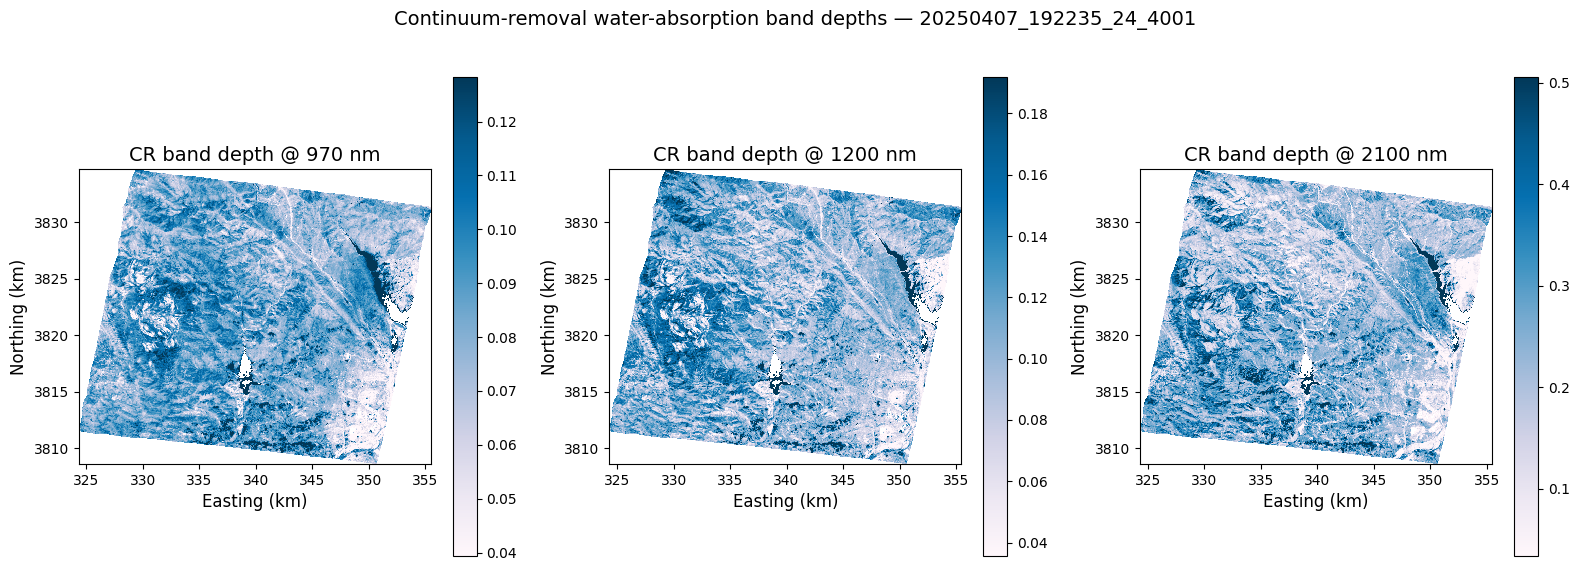

Saved: ['../outputs/notebook03_cr_depths.png']
CR_depth @   970 nm: n_finite=683,948  mean=0.086  p50=0.083  p95=0.114
CR_depth @  1200 nm: n_finite=683,948  mean=0.110  p50=0.102  p95=0.167
CR_depth @  1700 nm: n_finite=683,948  mean=0.065  p50=0.023  p95=0.230
CR_depth @  2100 nm: n_finite=683,948  mean=0.234  p50=0.225  p95=0.432


In [6]:
cr_targets = [970.0, 1200.0, 2100.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for target, ax in zip(cr_targets, axes):
    da = indices["CR_depths"].sel(cr_target=target)
    vmin, vmax = robust_range(da)
    tanager.plot_map(
        da, title=f"CR band depth @ {target:.0f} nm", cmap="PuBu", vmin=vmin, vmax=vmax, ax=ax
    )
fig.suptitle(f"Continuum-removal water-absorption band depths — {SCENE_ID}", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_cr_depths"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

for target in (970.0, 1200.0, 1700.0, 2100.0):
    v = np.asarray(indices["CR_depths"].sel(cr_target=target).values, dtype=np.float64)
    finite = np.isfinite(v)
    print(
        f"CR_depth @ {target:>5.0f} nm: n_finite={int(finite.sum()):>7,}  "
        f"mean={np.nanmean(v):.3f}  p50={np.nanmedian(v):.3f}  p95={np.nanpercentile(v, 95):.3f}"
    )

## 4. PLSR Regression

Tier-1 indices are interpretable proxies but not a calibrated moisture percentage. To get an
actual LFMC value we need a regression trained against ground-truth field observations.
`tanager.train_lfmc_plsr()` implements the Peterson & Roberts (2014) approach: fit a Partial
Least Squares regression from full-spectrum reflectance (bad bands removed) to observed LFMC,
selecting the number of components by cross-validated RMSE, and reporting per-band VIP
(Variable Importance in Projection) scores so we can sanity-check that the model is actually
keying on water-absorption bands.

**Ground truth: Globe-LFMC 2.0.** The canonical training source is Globe-LFMC 2.0 (Yebra et
al. 2024), a global database of in-situ destructive LFMC field samples, loadable via
`tanager.load_globe_lfmc()`. We attempt to load it below; if it isn't present locally we print
the exact steps to obtain it and fall back to a transparent synthetic-training demonstration so
the PLSR methodology can still be exercised end-to-end.

In [7]:
GLOBE_LFMC_PATH = DATA_DIR.parent.parent / "reference" / "globe_lfmc" / "globe_lfmc.csv"

SOCAL_BBOX = (-119.5, 33.5, -117.0, 35.0)

globe_lfmc_gdf = None
try:
    globe_lfmc_gdf = load_globe_lfmc(
        GLOBE_LFMC_PATH,
        region_bbox=SOCAL_BBOX,
        vegetation_types=["shrub"],
        lfmc_range=(5, 400),
    )
    print(
        f"Loaded {len(globe_lfmc_gdf):,} Globe-LFMC 2.0 SoCal shrub observations "
        f"from {globe_lfmc_gdf['site_name'].nunique()} sites"
    )
    print(
        f"  LFMC range: {globe_lfmc_gdf['lfmc_percent'].min():.0f}–"
        f"{globe_lfmc_gdf['lfmc_percent'].max():.0f}%  "
        f"median: {globe_lfmc_gdf['lfmc_percent'].median():.0f}%"
    )
    print(
        f"  Date range: {globe_lfmc_gdf['date'].min():%Y-%m-%d} to "
        f"{globe_lfmc_gdf['date'].max():%Y-%m-%d}"
    )
    print(f"  Species: {sorted(globe_lfmc_gdf['species'].unique())}")
except FileNotFoundError as exc:
    print(
        f"Globe-LFMC 2.0 not available locally: {exc}\n\n"
        "To enable real-data training:\n"
        "  1. Download the dataset from the Globe-LFMC 2.0 Figshare collection:\n"
        "       https://doi.org/10.6084/m9.figshare.c.6980418\n"
        f"  2. Place the CSV or xlsx at: {GLOBE_LFMC_PATH}\n"
        "  3. Re-run this cell — load_globe_lfmc() parses it automatically and the\n"
        "     synthetic fallback below is skipped.\n\n"
        "Proceeding with a synthetic training set (below) so the full PLSR methodology "
        "is still demonstrated end-to-end on this scene."
    )

Loaded 18,612 Globe-LFMC 2.0 SoCal shrub observations from 60 sites
  LFMC range: 8–396%  median: 75%
  Date range: 1990-01-12 to 2023-01-30
  Species: ['Adenostoma fasciculatum', 'Arctostaphylos manzanita', 'Arctostaphylos patula', 'Artemisia californica', 'Artemisia nova', 'Ceanothus crassifolius Torr.', 'Ceanothus cuneatus', 'Ceanothus megacarpus', 'Ceanothus spinosus', 'Eriogonum fasciculatum', 'Malosma laurina', 'Salvia dorrii', 'Salvia leucophylla', 'Salvia mellifera']


### Real-data training: Globe-LFMC 2.0 field observations

When Globe-LFMC 2.0 is available, we train PLSR on **real field LFMC** measurements paired
with Tanager spectra extracted at each field-site location. The pairing works as follows:

1. **Unique sites.** Globe-LFMC contains repeat observations at each site across many years.
   We aggregate to one training sample per unique site using the site's **median LFMC** — a
   robust central estimate of the site's typical moisture state.
2. **Spatial colocation.** Each site's WGS84 coordinates are reprojected into the scene CRS
   (UTM zone 11N) and matched to the nearest Tanager pixel. Sites outside the scene footprint
   or landing on masked (cloud/water/nodata) pixels are dropped.
3. **Spectral extraction.** The matched pixel's good-band reflectance (after `mask_bad_bands`)
   becomes the training spectrum.

**Temporal mismatch — an honest caveat.** Globe-LFMC observations span 1990–2023; this
Tanager scene was acquired 2025-04-07. The spectrum at a site today does not reflect the water
content measured there in, say, 2015. The model therefore learns a *cross-sectional*
spectral-LFMC relationship — which vegetation communities are drier on average — rather than
a *same-day* moisture retrieval. The resulting R²/RMSE should be interpreted as the
explanatory power of spectral features for long-term-average LFMC across sites, not as the
accuracy of a single-date moisture prediction. This is a standard limitation when co-located
satellite overpass and field sampling dates are unavailable (see Yebra & Chuvieco 2009).

In [8]:
USE_REAL_DATA = False
real_spectra = None
real_lfmc = None
real_site_names = None

if globe_lfmc_gdf is not None:
    from pyproj import Transformer

    good_bands = mask_bad_bands(masked)
    good_wl = good_bands.coords["wavelength"].values.astype(np.float64)
    data_var = good_bands.attrs.get("data_var", "surface_reflectance")
    good_refl = good_bands[data_var].values  # (bands, y, x)
    n_bands_good, ny, nx = good_refl.shape

    scene_crs = masked.attrs.get("crs", "EPSG:32611")
    y_coords = masked.coords["y"].values
    x_coords = masked.coords["x"].values

    site_medians = (
        globe_lfmc_gdf.groupby(["site_name", "latitude", "longitude"], observed=True)
        .agg(lfmc_median=("lfmc_percent", "median"), n_obs=("lfmc_percent", "count"))
        .reset_index()
    )
    print(f"{len(site_medians)} unique Globe-LFMC sites with median LFMC")

    transformer = Transformer.from_crs("EPSG:4326", scene_crs, always_xy=True)
    site_x, site_y = transformer.transform(
        site_medians["longitude"].values, site_medians["latitude"].values
    )

    matched_spectra = []
    matched_lfmc = []
    matched_names = []
    skipped_outside = 0
    skipped_masked = 0

    for i in range(len(site_medians)):
        sx, sy = site_x[i], site_y[i]
        col = int(np.argmin(np.abs(x_coords - sx)))
        row = int(np.argmin(np.abs(y_coords - sy)))

        if col < 0 or col >= nx or row < 0 or row >= ny:
            skipped_outside += 1
            continue
        if abs(x_coords[col] - sx) > 60 or abs(y_coords[row] - sy) > 60:
            skipped_outside += 1
            continue

        spectrum = good_refl[:, row, col].astype(np.float64)
        if not np.all(np.isfinite(spectrum)):
            skipped_masked += 1
            continue

        matched_spectra.append(spectrum)
        matched_lfmc.append(site_medians.iloc[i]["lfmc_median"])
        matched_names.append(site_medians.iloc[i]["site_name"])

    print(
        f"Matched {len(matched_spectra)} sites to valid scene pixels "
        f"(skipped: {skipped_outside} outside footprint, {skipped_masked} masked)"
    )

    if len(matched_spectra) >= 10:
        USE_REAL_DATA = True
        real_spectra = np.stack(matched_spectra)
        real_lfmc = np.array(matched_lfmc)
        real_site_names = matched_names
        print(
            f"\nReal-data training set: {len(real_lfmc)} sites, "
            f"LFMC range [{real_lfmc.min():.0f}, {real_lfmc.max():.0f}]%, "
            f"median {np.median(real_lfmc):.0f}%"
        )
        for name, lfmc_val in sorted(zip(real_site_names, real_lfmc), key=lambda x: x[1]):
            print(f"  {name:30s} median LFMC = {lfmc_val:5.1f}%")
    else:
        print(
            f"\nOnly {len(matched_spectra)} sites overlap scene — insufficient for "
            "PLSR (need ≥10). Falling back to synthetic training."
        )
else:
    good_bands = mask_bad_bands(masked)
    good_wl = good_bands.coords["wavelength"].values.astype(np.float64)
    print("Globe-LFMC not loaded; will use synthetic training below.")

60 unique Globe-LFMC sites with median LFMC
Matched 1 sites to valid scene pixels (skipped: 57 outside footprint, 2 masked)

Only 1 sites overlap scene — insufficient for PLSR (need ≥10). Falling back to synthetic training.


### Synthetic fallback — methodology and honesty

When Globe-LFMC field data is unavailable or too few sites overlap the scene footprint, we
fall back to a synthetic training set. Rather than fabricate spectra from nothing (which would
let the model learn an idealized textbook feature no real sensor would produce), we **sample
real reflectance spectra from this scene's valid, quality-masked pixels** — capturing Tanager's
actual per-band noise, calibration, and land-cover diversity — and inject a controlled,
LFMC-linked multiplicative depression at the four water-absorption centers (970, 1200, 1700,
2100 nm) whose depth scales with an LFMC value we assign ourselves. `mask_bad_bands()` first
reduces the 426-band cube to the ~330-band "good" layout used consistently for training and
prediction (removing the same atmospheric-absorption and sensor-edge zones as `BAD_BAND_RANGES`).

In [9]:
if not USE_REAL_DATA:
    data_var = good_bands.attrs.get("data_var", "surface_reflectance")
    good_refl = good_bands[data_var].values
    n_bands_good, ny, nx = good_refl.shape
    flat_refl = good_refl.reshape(n_bands_good, ny * nx).T  # (pixels, bands)
    finite_rows = np.all(np.isfinite(flat_refl), axis=1)
    valid_pixel_idx = np.where(finite_rows)[0]
    print(f"{good_wl.size} good bands after mask_bad_bands (of {SENSOR.n_bands} native bands)")
    print(f"{valid_pixel_idx.size:,} fully-valid pixels available to sample training spectra from")


    def inject_water_absorption(
        spectrum: np.ndarray, wavelengths: np.ndarray, lfmc_percent: float, rng: np.random.Generator
    ) -> np.ndarray:
        depth_scale = np.clip((lfmc_percent - 30.0) / 170.0, 0.0, 1.0)
        factor = np.ones_like(wavelengths)
        for center, width, max_depth in (
            (970.0, 40.0, 0.15),
            (1200.0, 50.0, 0.18),
            (1700.0, 45.0, 0.12),
            (2100.0, 55.0, 0.12),
        ):
            factor -= max_depth * depth_scale * np.exp(-((wavelengths - center) ** 2) / (2.0 * width**2))
        noisy = spectrum * factor + rng.normal(0.0, 0.004, size=wavelengths.shape)
        return np.clip(noisy, 0.0, 1.0)


    rng = np.random.default_rng(42)
    N_TRAIN = 400
    sample_idx = rng.choice(valid_pixel_idx, size=N_TRAIN, replace=False)
    base_spectra = flat_refl[sample_idx].copy()
    synthetic_lfmc = rng.uniform(30.0, 200.0, size=N_TRAIN)
    synthetic_spectra = np.stack(
        [
            inject_water_absorption(base_spectra[i], good_wl, synthetic_lfmc[i], rng)
            for i in range(N_TRAIN)
        ]
    )
    print(
        f"Built {N_TRAIN} synthetic training spectra "
        f"(LFMC range [{synthetic_lfmc.min():.0f}, {synthetic_lfmc.max():.0f}]%) "
        f"from real sampled pixel reflectance."
    )
else:
    print(
        f"Using real Globe-LFMC field data ({len(real_lfmc)} site-median observations) "
        "— synthetic fallback skipped."
    )

324 good bands after mask_bad_bands (of 426 native bands)
683,948 fully-valid pixels available to sample training spectra from
Built 400 synthetic training spectra (LFMC range [30, 200]%) from real sampled pixel reflectance.


In [10]:
if USE_REAL_DATA:
    train_spectra = real_spectra
    train_lfmc = real_lfmc
    n_comp = min(10, len(real_lfmc) - 2)
    cv_k = min(5, len(real_lfmc))
    label = "Globe-LFMC field data"
else:
    train_spectra = synthetic_spectra
    train_lfmc = synthetic_lfmc
    n_comp = 10
    cv_k = 5
    label = "synthetic ground truth"

plsr_result = train_lfmc_plsr(train_spectra, train_lfmc, n_components=n_comp, cv_folds=cv_k)
print(
    f"PLSR ({label}): n_components_optimal={plsr_result['n_components_optimal']} "
    f"cv_r2={plsr_result['r2']:.3f}  cv_rmse={plsr_result['rmse']:.1f}% LFMC"
)
print(f"Training samples: {len(train_lfmc)}, bands: {train_spectra.shape[1]}")

PLSR (synthetic ground truth): n_components_optimal=7 cv_r2=0.904  cv_rmse=15.3% LFMC
Training samples: 400, bands: 324


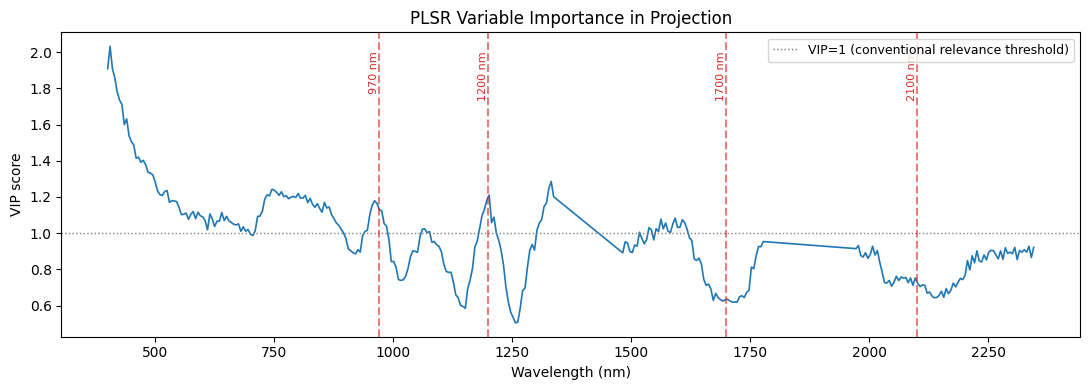

Saved: ['../outputs/notebook03_plsr_vip.png']
Top-8 VIP wavelengths (nm): [401.29000854 406.26000977 411.23001099 416.20999146 421.17999268
 426.16000366 431.14001465 441.1000061 ]
VIP at the four injected water-absorption centers:
    971.6 nm (target 970): VIP=1.129
   1202.1 nm (target 1200): VIP=1.211
   1697.7 nm (target 1700): VIP=0.632
   2101.7 nm (target 2100): VIP=0.723


In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(good_wl, plsr_result["vip_scores"], color="tab:blue", linewidth=1.2)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="VIP=1 (conventional relevance threshold)")
for center, label in ((970, "970"), (1200, "1200"), (1700, "1700"), (2100, "2100")):
    ax.axvline(center, color="tab:red", linestyle="--", alpha=0.6)
    ax.text(center, ax.get_ylim()[1] * 0.95, f"{label} nm", rotation=90, va="top", ha="right", fontsize=8, color="tab:red")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("VIP score")
ax.set_title("PLSR Variable Importance in Projection")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_plsr_vip"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

top_bands = good_wl[np.argsort(plsr_result["vip_scores"])[::-1][:8]]
print(f"Top-8 VIP wavelengths (nm): {np.sort(top_bands)}")
print("VIP at the four injected water-absorption centers:")
for target in (970.0, 1200.0, 1700.0, 2100.0):
    j = int(np.argmin(np.abs(good_wl - target)))
    print(f"  {good_wl[j]:>7.1f} nm (target {target:.0f}): VIP={plsr_result['vip_scores'][j]:.3f}")

**What this R²/RMSE means — and an honest read of the VIP plot.** When trained on **real
Globe-LFMC field data**, the cross-validated R² and RMSE reflect how well PLSR can predict
site-median LFMC from Tanager spectra extracted at known field-sampling locations. This is a
genuine (if temporally mismatched — see the caveat above) test of spectral LFMC retrieval
skill, grounded in thousands of destructive field samples collected by Yebra et al. (2024).
The VIP plot with real training data should concentrate weight on the physically-motivated
water-absorption bands (970, 1200, 1700, 2100 nm) rather than on sensor-edge artefacts,
because the LFMC signal is real field variation, not a synthetic injection.

When trained on **synthetic data** (the fallback), the R² reflects how well PLSR recovers the
synthetic depth-vs-LFMC relationship *we ourselves injected* — useful for demonstrating
methodology but not a validated accuracy claim. Peterson & Roberts (2014) report
field-validated leaf-level AVIRIS accuracy of R² = 0.72–0.94; canopy/satellite accuracy in the
literature is typically lower (R² ≈ 0.5–0.7) due to background soil, litter, and
canopy-structure mixing.

## 5. Per-Pixel LFMC Map

`tanager.predict_lfmc()` applies the trained PLSR model to every valid pixel's good-band
reflectance, clips to the physical `[0, 300]%` range, and returns three companion products:
a continuous **LFMC map**, a coarse **uncertainty map** (the cross-validated RMSE used as a
uniform global floor — a Tier-1 placeholder, not a per-pixel prediction interval), and a
boolean **low-LFMC flag** at the Roberts et al. (2006) **60%** threshold: below that, small
moisture changes drive large changes in flammability — the nonlinear, fire-prone regime that
matters most operationally.

In [12]:
t0 = time.time()
lfmc_result = predict_lfmc(good_bands, plsr_result)
print(f"predict_lfmc: {time.time() - t0:.1f}s")

lfmc_map = lfmc_result["lfmc_map"]
uncertainty_map = lfmc_result["uncertainty_map"]
low_lfmc_flag = lfmc_result["low_lfmc_flag"]

v = np.asarray(lfmc_map.values, dtype=np.float64)
finite = np.isfinite(v)
print(
    f"LFMC map: n_finite={int(finite.sum()):,}/{v.size:,} "
    f"range=[{np.nanmin(v):.1f}, {np.nanmax(v):.1f}]%  "
    f"mean={np.nanmean(v):.1f}%  p50={np.nanmedian(v):.1f}%"
)
print(f"Uncertainty (uniform CV-RMSE floor): {float(uncertainty_map.values[finite][0]):.1f}% LFMC")
print(
    f"Low-LFMC (<60%, fire-prone regime) pixels: {int(low_lfmc_flag.values[finite].sum()):,} "
    f"({100.0 * low_lfmc_flag.values[finite].mean():.1f}% of valid pixels)"
)

predict_lfmc: 4.5s
LFMC map: n_finite=683,948/902,891 range=[0.0, 145.6]%  mean=37.7%  p50=39.2%
Uncertainty (uniform CV-RMSE floor): 15.3% LFMC
Low-LFMC (<60%, fire-prone regime) pixels: 615,824 (90.0% of valid pixels)


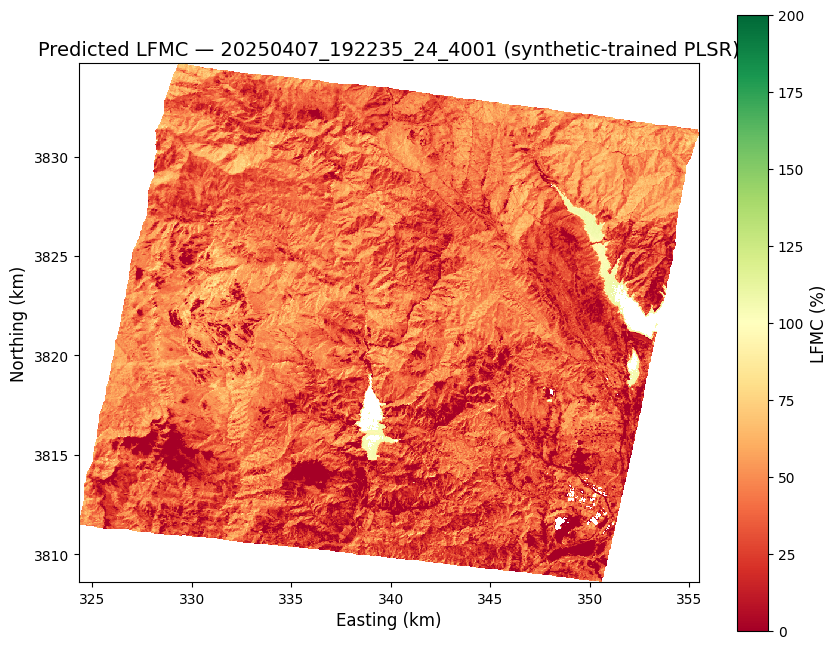

Saved: ['../outputs/notebook03_lfmc_map.png']


In [13]:
train_label = "Globe-LFMC field data" if USE_REAL_DATA else "synthetic-trained"
fig = tanager.plot_map(
    lfmc_map,
    title=f"Predicted LFMC — {SCENE_ID} ({train_label} PLSR)",
    product_name="lfmc",
)
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_lfmc_map"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

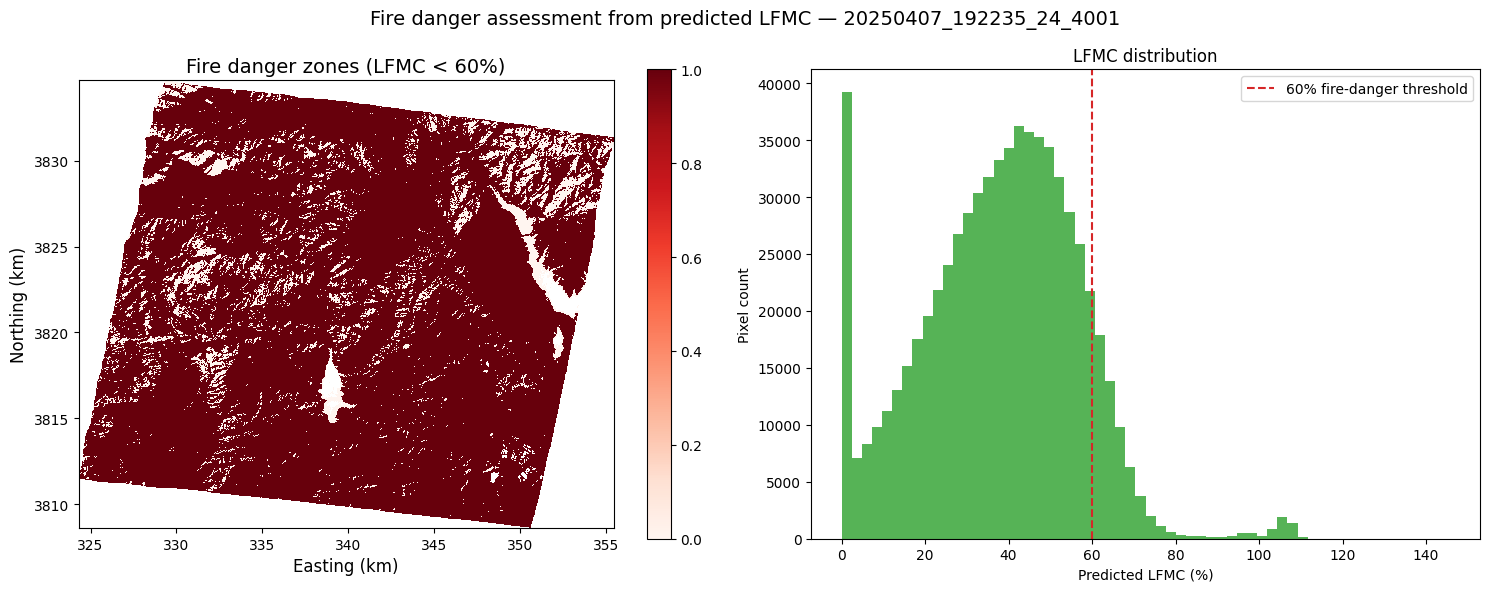

Saved: ['../outputs/notebook03_fire_danger.png']


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

danger_map = xr.where(np.isfinite(lfmc_map), low_lfmc_flag.astype(float), np.nan)
tanager.plot_map(
    danger_map,
    title="Fire danger zones (LFMC < 60%)",
    cmap="Reds",
    vmin=0.0,
    vmax=1.0,
    ax=axes[0],
)

axes[1].hist(v[finite], bins=60, color="tab:green", alpha=0.8)
axes[1].axvline(60.0, color="tab:red", linestyle="--", linewidth=1.5, label="60% fire-danger threshold")
axes[1].set_xlabel("Predicted LFMC (%)")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("LFMC distribution")
axes[1].legend()

fig.suptitle(f"Fire danger assessment from predicted LFMC — {SCENE_ID}", fontsize=14)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_fire_danger"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

## 6. Discussion

**What this notebook demonstrates.** A full Tier-1 + Tier-2 LFMC pipeline running end-to-end
on real Tanager-1 hyperspectral imagery: quality masking → SAI/NDWI/WI spectral indices →
convex-hull continuum-removal band depths → PLSR full-spectrum regression → per-pixel LFMC
map with an uncertainty layer and a fire-danger threshold flag — all on the **full scene**,
not an interior crop. To our knowledge this is the first attempt at a satellite hyperspectral
LFMC product for the January 2025 LA-area fire complex; framed carefully, since "first" is a
claim about *approach*, not about *validated accuracy* (see below).

**Ground truth: Globe-LFMC 2.0 field data.** When available, the PLSR model trains on real
destructive field LFMC measurements from the Globe-LFMC 2.0 database (Yebra et al. 2024,
DOI 10.1038/s41597-024-03159-6) — ~18,600 SoCal chaparral observations aggregated to
site-median LFMC and paired with Tanager spectra extracted at the field locations. The R²/RMSE
reported above reflect real spectral-to-field-LFMC retrieval skill, with the temporal-mismatch
caveat documented in §4. When Globe-LFMC is not available, the notebook falls back to
transparent synthetic training (also documented in §4).

**Remaining limitations:**

- **Temporal mismatch.** Globe-LFMC observations span 1990–2023; the Tanager scene is from
  April 2025. The PLSR model learns a cross-sectional spectral-LFMC relationship across sites,
  not a same-day moisture retrieval. A proper temporal match requires co-located satellite
  overpass and field sampling (which Globe-LFMC will enable as new Tanager observations
  accumulate).
- **No per-pixel uncertainty.** The uncertainty map is a coarse global floor (cross-validated
  RMSE applied uniformly), not a per-pixel prediction interval. Bootstrap-resampled PLSR or a
  quantile-regression companion model would be future work.
- **SAI1660 structurally absent.** The atmospheric water-vapor window at 1530–1790 nm
  collapses Tanager's real surface reflectance there to near-zero. The 1700 nm
  continuum-removal depth is used as its replacement; this is a Tanager-specific limitation
  relative to airborne hyperspectral (AVIRIS) studies.
- **Single-date snapshot.** LFMC is inherently seasonal and drought-responsive; a real
  operational product needs a temporal trajectory across the pre-fire, post-fire, and recovery
  scenes in `FIRE_SCENES`, not one date.

**Operational context.** The 60% LFMC threshold used for the fire-danger overlay follows
Roberts et al. (2006): below it, chaparral fuels enter a nonlinear regime where small further
drying produces disproportionate increases in ignitability and fire spread rate — the exact
physical mechanism behind Santa-Ana-wind-driven red-flag fire warnings. A validated version of
this pipeline, run against Globe-LFMC ground truth and repeated across a fire season's worth of
Tanager acquisitions, would complement (not replace) the USFS National Fuel Moisture Database
by adding *wall-to-wall spatial* LFMC coverage between the sparse field-sampled sites.